In [1]:
import json
import numpy as np
from PIL import Image
import os


In [2]:
gt_path = 'data_backup/formalgeo7k/formalgeo7k_v2/problems_withAns'
pred_path = 'outputs/report/bunny-yi1.5-9B-Chat-FormalGeoCoT-VisionPretrained-sft1e-v17'
image_path = 'data_backup/formalgeo7k/formalgeo7k_v2/diagrams'

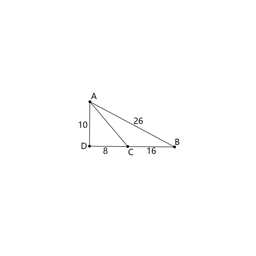

Using the provided geometric image, construction_cdl, image_cdl, and question, give a detailed step-by-step solution. Note that there may be minor errors in the construction_cdl and image_cdl.
The construction_cdl is:
Shape(AD,DC,CA),Shape(AC,CB,BA),Collinear(DCB)
The image_cdl is:
Equal(LengthOfLine(AB),26),Equal(LengthOfLine(AD),10),Equal(LengthOfLine(BC),16),Equal(LengthOfLine(DC),8)
The question is:
As shown in the diagram, AB=26, AD=10, CB=16, DC=8, AD is the altitude of △ ACB. Find the area of triangle ACB.



Shape(AD,DC,CA),Shape(AC,CB,BA),Collinear(DCB)



Equal(LengthOfLine(AB),26),Equal(LengthOfLine(AD),10),Equal(LengthOfLine(BC),16),Equal(LengthOfLine(DC),8)



由题意得，AD=10（1），AD是三角形ACB的高（2），CB=16（3）；
已知条件（1）（2），计算可得，Height(△ACB)=10（4）；
由三角形面积公式（底乘高除2）可得，Area(△ACB)=Height(△ACB)×CB/2（5）；
已知条件（4）（3）（5），计算可得，Area(△ACB)=80（6）；
完成解题。



Step 1: Identify the given information:
- AB = 26
- AD = 10
- BC = 16
- DC = 8
- AD is the altitude of triangle ACB

Step 2: Use the formula for t

In [6]:
with open('data_backup/formalgeo7k/formalgeo7k_v2/test.json', 'r') as f:
    test_prob_ids = json.load(f).keys()
test_prob_ids = list(test_prob_ids)

idx = 999
prob_id = test_prob_ids[idx]

image = Image.open(os.path.join(image_path, f'{prob_id}.png'))

# 读取GT
with open(os.path.join(gt_path, f'{prob_id}.json'), 'r') as f:
    gt_info = json.load(f)
gt_solution = gt_info['formalSSS_Solution']
gt_origin_qa = gt_info['origin_qa']
model_predict_consCDL = gt_info['model_predict_consCDL']
model_predict_imageCDL = gt_info['model_predict_imageCDL']

# 读取预测信息
pred_dict = {}
with open(os.path.join(pred_path, 'formalgeo_test_qs_meta_Q+PredCDL2Ans_merged.jsonl'), 'r') as f:
    for line in f:
        cur_info = json.loads(line)
        pred_dict[cur_info['question_id']] = cur_info

pred_info = pred_dict[prob_id]
prompt = pred_info['prompt']
pred_solution = pred_info['text']


display(image.resize((256, 256)))
print(prompt + '\n\n\n')
print(model_predict_consCDL + '\n\n\n')
print(model_predict_imageCDL + '\n\n\n')
print(gt_solution + '\n\n\n' )
print(pred_solution + '\n\n\n')
